In [22]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt  

from sklearn.model_selection import train_test_split,cross_val_score  
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.svm import SVR 

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.datasets import make_regression 
from sklearn.ensemble import VotingRegressor


In [46]:
X,y = make_regression(n_features=4,n_targets=1,n_informative=5,noise=0.1,random_state= 42)

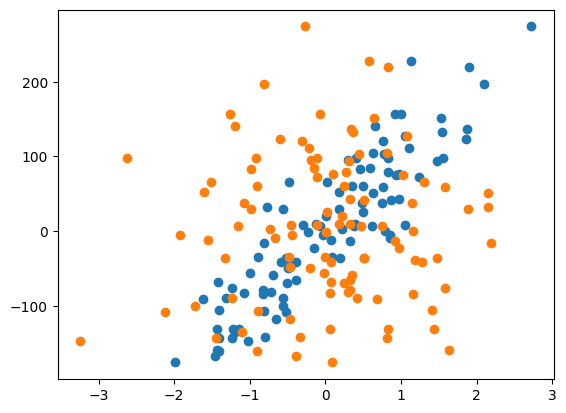

In [47]:
plt.scatter(X[:,0],y)
plt.scatter(X[:,1],y)

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

In [49]:
lr = LinearRegression() 
rf = RandomForestRegressor(random_state= 42) 
svr = SVR()

In [50]:
estimators = [('lr',lr),('rf',rf),('svr',svr)] 

In [51]:
ve = VotingRegressor(estimators=estimators)

In [53]:
models = [('Linear Regression',lr),('Random Forest',rf),('SVR',svr),('Voting Regressor',ve)] 

print(f"{'Model':<20} | {'R2 Score':<10} | {'MAE':<10}")
print("-" * 42)
for name, model in models: 
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test) 
    r2 = r2_score(y_test,y_pred) 
    mae = mean_absolute_error(y_test,y_pred) 
    print(f"{name:<20} | {r2:<10.2f} | {mae:<10.3f}")

Model                | R2 Score   | MAE       
------------------------------------------
Linear Regression    | 1.00       | 0.089     
Random Forest        | 0.90       | 18.282    
SVR                  | 0.01       | 67.654    
Voting Regressor     | 0.85       | 26.675    


In [57]:
cv = cross_val_score(ve,X,y,scoring='r2')

In [64]:
cv.mean()

np.float64(0.8335505474949704)

## Weights Adjusting 

In [66]:
for i in range(1,4): 
    for j in range(1,4): 
        for k in range(1,4): 
            ve_w= VotingRegressor(estimators=estimators, weights= [i,j,k]) 
            cv_w = cross_val_score(ve_w, X,y, scoring='r2')
            print(f"For i= {i}, j = {j} , k= {k}  R2: {round(np.mean(cv_w),2)}")

For i= 1, j = 1 , k= 1  R2: 0.83
For i= 1, j = 1 , k= 2  R2: 0.7
For i= 1, j = 1 , k= 3  R2: 0.6
For i= 1, j = 2 , k= 1  R2: 0.86
For i= 1, j = 2 , k= 2  R2: 0.76
For i= 1, j = 2 , k= 3  R2: 0.68
For i= 1, j = 3 , k= 1  R2: 0.86
For i= 1, j = 3 , k= 2  R2: 0.79
For i= 1, j = 3 , k= 3  R2: 0.72
For i= 2, j = 1 , k= 1  R2: 0.91
For i= 2, j = 1 , k= 2  R2: 0.81
For i= 2, j = 1 , k= 3  R2: 0.72
For i= 2, j = 2 , k= 1  R2: 0.91
For i= 2, j = 2 , k= 2  R2: 0.83
For i= 2, j = 2 , k= 3  R2: 0.76
For i= 2, j = 3 , k= 1  R2: 0.91
For i= 2, j = 3 , k= 2  R2: 0.85
For i= 2, j = 3 , k= 3  R2: 0.79
For i= 3, j = 1 , k= 1  R2: 0.94
For i= 3, j = 1 , k= 2  R2: 0.87
For i= 3, j = 1 , k= 3  R2: 0.8
For i= 3, j = 2 , k= 1  R2: 0.94
For i= 3, j = 2 , k= 2  R2: 0.88
For i= 3, j = 2 , k= 3  R2: 0.82
For i= 3, j = 3 , k= 1  R2: 0.93
For i= 3, j = 3 , k= 2  R2: 0.88
For i= 3, j = 3 , k= 3  R2: 0.83
